In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import inspect
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from itertools import product
import shutup
from sklearn.preprocessing import StandardScaler
shutup.please()

In [3]:
df = pd.read_csv('datasets/winequality-red.csv')
df.columns.isnull()

array([False, False, False, False, False, False, False, False, False,
       False, False, False])

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import KNeighborsRegressor


def knn_regressor(
    X,
    y,
    test_size=0.25,
    n_neighbors_range=range(1, 15),
    monte_carlo_iterations=49,
    validation_size=None,  # NEW: for 3-way split
    cv=None,               # NEW: number of folds
    plot_results=True
):
    """
    KNN regression supporting pseudo Monte Carlo, 3-way split, or K-Fold CV.
    """

    cv_train = pd.DataFrame()
    cv_test = pd.DataFrame()
    cv_val = pd.DataFrame()  # validation scores

    # ----------------------------
    # SINGLE SPLIT (baseline curve)
    # ----------------------------
    if validation_size is None:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        use_validation = False
    else:
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        val_fraction = validation_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_fraction, random_state=42
        )
        use_validation = True
        print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

    # Single split accuracy curve
    train_scores = []
    test_scores = []
    val_scores = []

    for n in n_neighbors_range:
        reg = KNeighborsRegressor(n_neighbors=n)
        reg.fit(X_train, y_train)

        train_scores.append(reg.score(X_train, y_train))
        test_scores.append(reg.score(X_test, y_test))
        if use_validation:
            val_scores.append(reg.score(X_val, y_val))

    plt.figure(figsize=(12, 5))
    plt.plot(n_neighbors_range, train_scores, label="Training $R^2$")
    plt.plot(n_neighbors_range, test_scores, label="Test $R^2$")
    if use_validation:
        plt.plot(n_neighbors_range, val_scores, label="Validation $R^2$")
    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy ($R^2$)")
    plt.title("KNN Regression Accuracy vs. n_neighbors (Single Split)")
    plt.legend()
    plt.show()

    # ----------------------------
    # K-FOLD CROSS VALIDATION
    # ----------------------------
    if cv is not None:
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
            X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
            y_train_cv, y_test_cv = y[train_idx], y[test_idx]

            train_fold = []
            test_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train_cv, y_train_cv)
                train_fold.append(reg.score(X_train_cv, y_train_cv))
                test_fold.append(reg.score(X_test_cv, y_test_cv))

            cv_train[fold] = train_fold
            cv_test[fold] = test_fold

        title = f"{cv}-Fold CV KNN Regression Accuracy"

    # ----------------------------
    # 3-WAY SPLIT MONTE CARLO
    # ----------------------------
    elif validation_size is not None:
        for seed in range(1, monte_carlo_iterations + 1):
            X_train_val, X_test, y_train_val, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )
            val_fraction = validation_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_train_val, y_train_val, test_size=val_fraction, random_state=seed
            )

            train_fold = []
            test_fold = []
            val_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train, y_train)
                train_fold.append(reg.score(X_train, y_train))
                test_fold.append(reg.score(X_test, y_test))
                val_fold.append(reg.score(X_val, y_val))

            cv_train[seed] = train_fold
            cv_test[seed] = test_fold
            cv_val[seed] = val_fold

        title = "3-Way Split Monte Carlo KNN Regression Accuracy"

    # ----------------------------
    # PSEUDO MONTE CARLO (default)
    # ----------------------------
    else:
        for seed in range(1, monte_carlo_iterations + 1):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=seed
            )

            train_fold = []
            test_fold = []

            for n in n_neighbors_range:
                reg = KNeighborsRegressor(n_neighbors=n)
                reg.fit(X_train, y_train)
                train_fold.append(reg.score(X_train, y_train))
                test_fold.append(reg.score(X_test, y_test))

            cv_train[seed] = train_fold
            cv_test[seed] = test_fold

        title = "Pseudo Monte Carlo KNN Regression Accuracy"

    # ----------------------------
    # PLOT MEAN + ERROR
    # ----------------------------
    plt.figure(figsize=(12, 5))
    plt.errorbar(n_neighbors_range, cv_train.mean(axis=1), yerr=cv_train.std(axis=1), label="Training $R^2$")
    plt.errorbar(n_neighbors_range, cv_test.mean(axis=1), yerr=cv_test.std(axis=1), label="Test $R^2$")
    if not cv_val.empty:
        plt.errorbar(n_neighbors_range, cv_val.mean(axis=1), yerr=cv_val.std(axis=1), label="Validation $R^2$")
    plt.xlabel("n_neighbors")
    plt.ylabel("Accuracy ($R^2$)")
    plt.title(title)
    plt.legend()
    plt.show()

    return cv_train, cv_test, cv_val

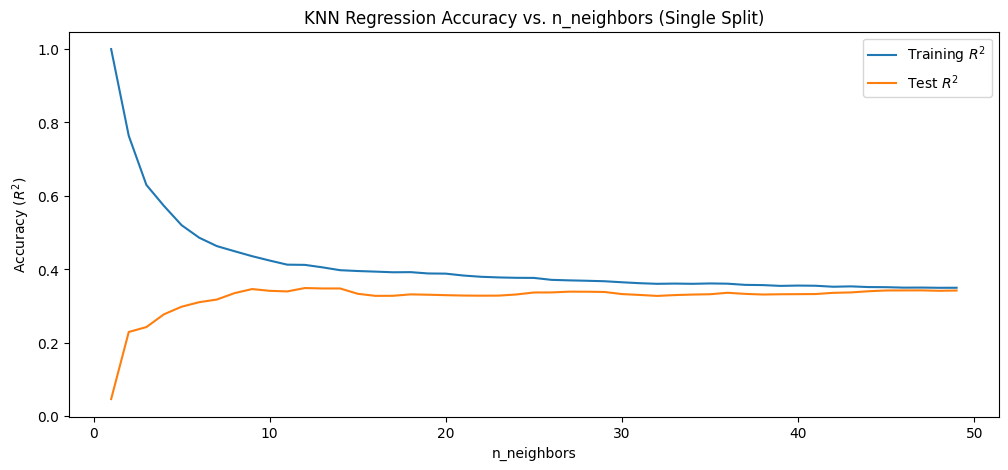

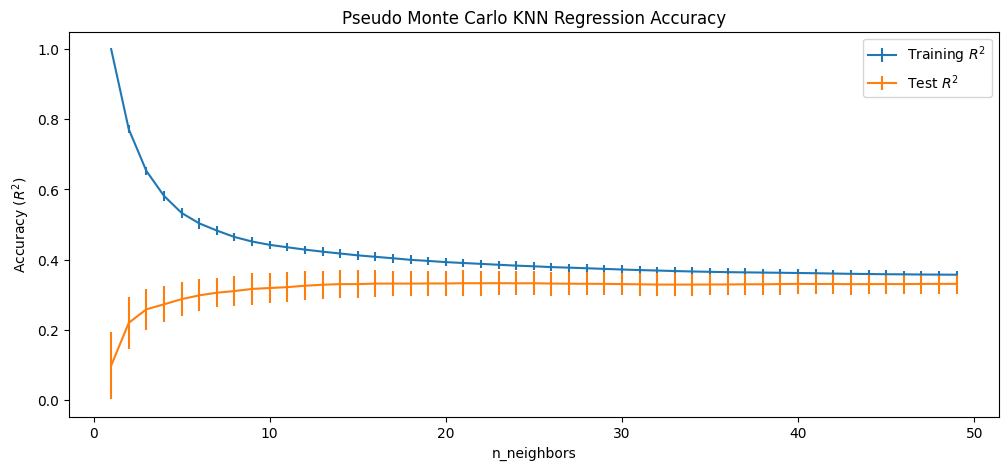

KeyError: 0

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='quality')
y = df['quality']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run KNN for k=5 with single split
train_scores, test_scores, _ = knn_regressor(
    X=X_scaled, 
    y=y, 
    n_neighbors_range=range(1,50), 
    monte_carlo_iterations=50,

)



print(f"Training R²: {train_scores[0]:.3f}")
print(f"Test R²: {test_scores[0]:.3f}")

Training R²: 0.412
Test R²: 0.349
Best k: 12 with Test R²: 0.349


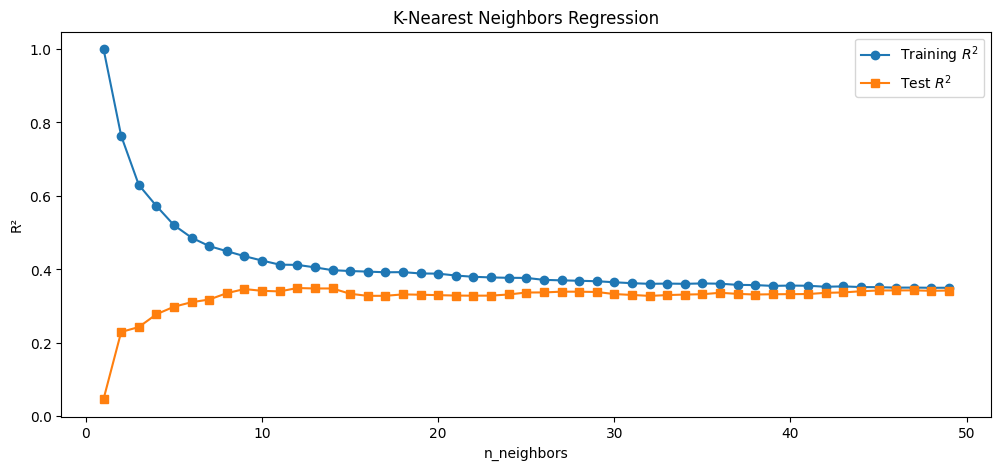

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
X = df.drop(columns='quality')
y = df['quality']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

knn = KNeighborsRegressor(n_neighbors=12)
knn.fit(X_train, y_train)
train_score = knn.score(X_train, y_train)
test_score = knn.score(X_test, y_test)
print(f"Training R²: {train_score:.3f}")
print(f"Test R²: {test_score:.3f}")

training_acc= []
test_acc = []
neighbrs_range = range(1, 50)
for k in neighbrs_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    training_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))
plt.figure(figsize=(12, 5))
plt.plot(neighbrs_range, training_acc, label="Training $R^2$", marker='o')
plt.plot(neighbrs_range, test_acc, label="Test $R^2$", marker='s')
plt.xlabel("n_neighbors")
plt.ylabel("R²")
plt.title("K-Nearest Neighbors Regression")
plt.legend()

best_k = neighbrs_range[np.argmax(test_acc)]
print(f"Best k: {best_k} with Test R²: {max(test_acc):.3f}")

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print(f'coefficients: {lin_reg.coef_}')
print(f'intercept: {lin_reg.intercept_}')

train_score = lin_reg.score(X_train, y_train)
test_score = lin_reg.score(X_test, y_test)
print(f"Linear Regression Training R²: {train_score:.3f}")
print(f"Linear Regression Test R²: {test_score:.3f}")

ypred = lin_reg.predict(X_test)
# Visualize
plt.figure(figsize=(12, 5))


coefficients: [ 0.03804852 -0.18056018 -0.02607653  0.01248727 -0.08260099  0.05237372
 -0.1201705  -0.03060987 -0.053083    0.13892165  0.30492871]
intercept: 5.633957834515446
Linear Regression Training R²: 0.355
Linear Regression Test R²: 0.372


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

lin_reg = Ridge(alpha=1.0)
lin_reg.fit(X_train, y_train)

print(f'coefficients: {lin_reg.coef_}')
print(f'intercept: {lin_reg.intercept_}')

train_score = lin_reg.score(X_train, y_train)
test_score = lin_reg.score(X_test, y_test)
print(f"Linear Regression Training R²: {train_score:.3f}")
print(f"Linear Regression Test R²: {test_score:.3f}")

ypred = lin_reg.predict(X_test)
# Visualize
plt.figure(figsize=(12, 5))


coefficients: [ 0.03848027 -0.18035805 -0.02577449  0.01266038 -0.08256489  0.0521999
 -0.12002362 -0.03121309 -0.05266487  0.13890781  0.30435113]
intercept: 5.63395253763336
Linear Regression Training R²: 0.355
Linear Regression Test R²: 0.372


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

coefficients: [-0.180808   -0.11148717  0.12914361  0.03759895  0.08594863  0.12820489
  0.1651896  -0.00972715 -0.06283793 -0.04858064  0.25249654 -0.11012838
  0.12208574 -0.08000736 -0.27505863 -0.08065923 -0.14081212 -0.20846062
  0.84133111 -0.03909012 -0.39442569  0.04032291 -0.05532309  0.03594891
 -0.09094818  0.34011901 -0.12117444 -0.313177    0.03407609  0.33375284
  0.02321521  0.10359674  0.06392826  0.06955219  0.11865311 -1.06329796
 -0.07846106  0.60195646  0.11343713  0.10592541 -0.01458224  0.01150527
  0.11937463 -0.00509534 -0.16627807 -0.22657141  0.08407658  0.09559386
 -0.07995089 -0.070768    0.04257073 -0.06309258  0.13379654 -0.03917397
 -0.16379138  0.22386252  0.13476124 -0.23275286 -0.23636537 -0.20065924
 -0.04015636 -0.06325726  0.26554755  0.25972758 -0.31767314  0.23470828]
intercept: 5.633515891928307
Linear Regression Training R²: 0.410
Linear Regression Test R²: 0.399


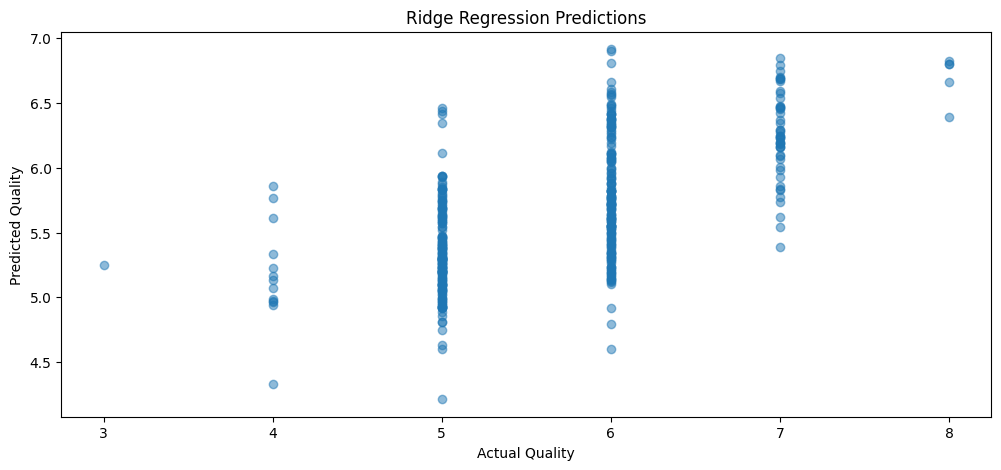

In [26]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

# Separate features and target
X = df.drop(columns='quality')
y = df['quality']

# Create interaction features (all pairwise products)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Fit Ridge regression
lin_reg = Ridge(alpha=1.0)
lin_reg.fit(X_train, y_train)

print(f'coefficients: {lin_reg.coef_}')
print(f'intercept: {lin_reg.intercept_}')

train_score = lin_reg.score(X_train, y_train)
test_score = lin_reg.score(X_test, y_test)
print(f"Linear Regression Training R²: {train_score:.3f}")
print(f"Linear Regression Test R²: {test_score:.3f}")

# Predict
y_pred = lin_reg.predict(X_test)

# Visualize predicted vs actual
plt.figure(figsize=(12, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Ridge Regression Predictions')
plt.show()